In [1]:
import pandas as pd
import numpy as np

In [3]:
df0 = pd.read_csv('C:/Users/arj26323/Documents/Data/Restoration_trends/fixed_restoration_window_trends_3.csv') ##3x3 window

df = df0.iloc[:, [3,4,5] + list(range(6,47))].dropna() ##FOR ORIGINALS

df

,Site name,Installation_year,type,geometry,biomass_1984,biomass_1985,biomass_1986,biomass_1987,biomass_1988,biomass_1989,...,biomass_2014,biomass_2015,biomass_2016,biomass_2017,biomass_2018,biomass_2019,biomass_2020,biomass_2021,biomass_2022,biomass_2023
0,Plantation Creek Site,2010,Oyster Reef,POINT (-81.477183 31.122967),415.569183,596.696716,424.160248,444.760101,454.666901,633.744324,...,468.044190,664.676269,467.191315,615.905273,478.254791,434.525177,714.136902,823.788635,479.731964,464.357910
1,Florida Passage Site,2012,Oyster Reef,POINT (-81.15333333 31.83865),546.787598,628.008118,713.233459,566.339539,714.556763,735.787537,...,392.914490,673.458801,477.707764,490.022613,480.411011,418.332519,560.940308,493.276245,459.225952,502.592590
2,Oatland Site,2014,Oyster Reef,POINT (-81.01923333 32.04801667),454.848907,431.684174,551.176636,462.359711,528.941162,523.316772,...,409.996338,560.010925,399.928101,434.612732,431.465637,378.262756,505.979706,516.557861,391.161011,401.994263
4,Estuaries Area of the Altamaha River,2009,Oyster Reef,POINT (-81.32228333 31.32615),432.954224,432.954224,346.108185,367.529571,435.826538,432.954224,...,1785.122437,1951.631470,1691.542358,1945.601929,1816.893677,1365.065308,1973.961060,1929.251587,1754.852905,1458.545532
5,Jekyll Island Boat Ramp Site,2009,Oyster Reef,POINT (-81.42301667 31.04165),426.000030,584.057495,406.831421,387.468353,468.236969,562.722290,...,403.886597,589.351074,412.766602,562.577576,411.958008,411.658356,465.735260,575.580261,408.291718,419.075836
7,Oyster Creek Site B,2013,Oyster Reef,POINT (-80.91488333 32.00441667),239.060226,372.658814,358.286591,291.562958,369.751556,366.183044,...,251.925461,379.952362,205.888474,232.572906,215.731125,246.284225,249.831177,214.575150,207.701630,215.857468
9,Jointer Creek Oyster Reef A,2012,Oyster Reef,POINT (-81.50021667 31.0808),280.419067,399.076416,300.492676,347.091125,369.082184,375.255920,...,246.608215,368.636231,251.039337,361.807617,229.932373,265.036041,363.710510,365.909576,254.114487,320.252197
10,Jointer Creek Oyster Reef B,2012,Oyster Reef,POINT (-81.49396667 31.0796),289.923523,397.946197,302.668671,360.008637,337.579590,381.647827,...,274.967621,381.692657,266.043488,378.523407,241.847824,267.323761,389.814179,370.218231,254.134232,271.862732
11,Jointer Creek Oyster Reef C,2012,Oyster Reef,POINT (-81.49078333 31.08058333),324.102203,431.120758,335.510895,355.180176,337.854858,380.114990,...,262.336914,375.519836,249.687531,361.999756,234.102936,269.492859,398.049225,368.151306,257.852875,271.058777
12,Jointer Creek Oyster Reef D,2012,Oyster Reef,POINT (-81.47005 31.0704),389.009094,544.705017,405.797211,418.006592,403.280395,508.578888,...,369.914581,668.582764,369.886169,505.491394,675.972778,384.359161,470.159119,603.878601,355.689270,916.806274


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

##With LS site updates, you need this:
df['Site'] = df['Site name']
df['Install_year'] = df['Installation_year'] ##manually changed from 'year' in output

df = df.drop(columns=['Site name', 'Installation_year', 'geometry'])

# 1. Melt the DataFrame
# Assumes 'site' is the column that identifies your locations
df_long = pd.melt(
    df, 
    id_vars=['Site', 'Install_year', 'type'], 
    var_name='year', 
    value_name='biomass'
)

# 2. Clean the 'year' column
# Remove 'biomass_' prefix and convert to numeric
df_long['year'] = df_long['year'].str.replace('biomass_', '').astype(int)

In [5]:
'''##SYNTHETIC CONTROLS
df0 = pd.read_csv('C:/Users/arj26323/Documents/Data/GA_conservation/synthetic_contols/synthetic_controls_3.csv') ##3x3 window
##NOTE THE DIFFERENT FILE PATH ON SYNTHETIC CONTROLS VS. ORIGINALS

df = df0.iloc[:, [1,2,3,4,5] + list(range(10,51))].dropna() ##FOR SYNTHETIC CONTROLS

df['Installation_year'] = df['year']
df['Install_year'] = df['year']

df['Site'] = df['Site name']

df

df = df.drop(columns=['Site name', 'Installation_year', 'geometry', 'year', 'Latitude', 'Longitude'])

# 1. Melt the DataFrame
# Assumes 'site' is the column that identifies your locations
df_long = pd.melt(
    df, 
    id_vars=['Site', 'Install_year', 'type'], 
    var_name='year', 
    value_name='biomass'
)

# 2. Clean the 'year' column
# Remove 'biomass_' prefix and convert to numeric
df_long['year'] = df_long['year'].str.replace('biomass_', '').astype(int)

df_long'''

"##SYNTHETIC CONTROLS\ndf0 = pd.read_csv('C:/Users/arj26323/Documents/Data/GA_conservation/synthetic_contols/synthetic_controls_3.csv') ##3x3 window\n##NOTE THE DIFFERENT FILE PATH ON SYNTHETIC CONTROLS VS. ORIGINALS\n\ndf = df0.iloc[:, [1,2,3,4,5] + list(range(10,51))].dropna() ##FOR SYNTHETIC CONTROLS\n\ndf['Installation_year'] = df['year']\ndf['Install_year'] = df['year']\n\ndf['Site'] = df['Site name']\n\ndf\n\ndf = df.drop(columns=['Site name', 'Installation_year', 'geometry', 'year', 'Latitude', 'Longitude'])\n\n# 1. Melt the DataFrame\n# Assumes 'site' is the column that identifies your locations\ndf_long = pd.melt(\n    df, \n    id_vars=['Site', 'Install_year', 'type'], \n    var_name='year', \n    value_name='biomass'\n)\n\n# 2. Clean the 'year' column\n# Remove 'biomass_' prefix and convert to numeric\ndf_long['year'] = df_long['year'].str.replace('biomass_', '').astype(int)\n\ndf_long"

In [6]:
df_long['Site'].unique()

array(['Plantation Creek Site', 'Florida Passage Site', 'Oatland Site',
       'Estuaries Area of the Altamaha River',
       'Jekyll Island Boat Ramp Site', 'Oyster Creek Site B',
       'Jointer Creek Oyster Reef A', 'Jointer Creek Oyster Reef B',
       'Jointer Creek Oyster Reef C', 'Jointer Creek Oyster Reef D',
       'Turtle A', 'Turtle B', 'Turtle C', 'Turtle D', 'Turtle E',
       'Bellville Boat Ramp Site', 'Ashantilly, Sapelo Island',
       'Long Tabby, Sapelo Island',
       "Mosquito Creek, Little St. Simon's Island",
       "Cannon's Point Preserve, St. Simon's Island",
       'Skidaway Island State Park, Skidaway Island',
       'Burton 4-H, Tybee Island',
       'Beach Road Bridge, Little St. Simons Island',
       'Little Cumberland Island', 'Fortson Pond, Jekyll Island',
       "DNR's Coastal Regional Headquarters, Brunswick", 'Jekyll TLP'],
      dtype=object)

In [7]:
'''##Adding installation year
df2 = pd.read_csv('C:/Users/arj26323/Documents/Data/GA_conservation/all_active_years_installations.csv')

df2['Install_year'] = df2['year']
df2['Site'] = df2['Site name']


df_insta = df2[['Site', 'Install_year']].copy()

# df_insta[df_insta['Site'] == "Mosquito Creek, Little St. Simon's Island"]
# df_insta'''

'##Adding installation year\ndf2 = pd.read_csv(\'C:/Users/arj26323/Documents/Data/GA_conservation/all_active_years_installations.csv\')\n\ndf2[\'Install_year\'] = df2[\'year\']\ndf2[\'Site\'] = df2[\'Site name\']\n\n\ndf_insta = df2[[\'Site\', \'Install_year\']].copy()\n\n# df_insta[df_insta[\'Site\'] == "Mosquito Creek, Little St. Simon\'s Island"]\n# df_insta'

In [8]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Remove leading/trailing whitespace
df_long['Site'] = df_long['Site'].str.strip()
'''df_insta['Site'] = df_insta['Site'].str.strip()
'''
# Normalize apostrophes: Replace curly/smart quotes with standard straight quotes
df_long['Site'] = df_long['Site'].str.replace("’", "'").str.replace("`", "'")
'''df_insta['Site'] = df_insta['Site'].str.replace("’", "'").str.replace("`", "'")
'''
'''df_long_install = pd.merge(df_long, df_insta, on = 'Site')

df_long_install = df_long_install[df_long_install['Site'] != "DNR's Coastal Regional Headquarters, Brunswick"] ##FLATS issues?'''

'''g = sns.FacetGrid(df_long_install, col="Site", col_wrap=4, height=3, sharey=True)
g.map(sns.scatterplot, "year", "biomass", marker='o', color = 'black')
# g.set_titles("{col_name}")
for site_name, ax in g.axes_dict.items():
    # Truncate the key string, not the axis object
    display_name = site_name if len(site_name) <= 30 else site_name[:30] + "..."
    
    # Set the title on the correct axis
    ax.set_title(display_name)
    
    # Get install year for this site
    install_year = (
        df_long_install.loc[df_long_install["Site"] == site_name, "Install_year"]
        .iloc[0]
    )

    # Add vertical dotted line
    ax.axvline(
        x=install_year,
        linestyle=":",
        color="red",
        linewidth=1.5
    )



g.set_axis_labels("", "AGB (g/$m^2$)")
g.set(ylim=(0, None))
plt.tight_layout()'''


# ##Save at high res
# import os
# output_dir = r'F:\Figures_PaperII'
# file_name = 'resorationsitetrends.tif'

# save_path = os.path.join(output_dir, file_name)

# # plt.savefig(save_path, bbox_inches='tight', dpi=1000)

# plt.show()

'g = sns.FacetGrid(df_long_install, col="Site", col_wrap=4, height=3, sharey=True)\ng.map(sns.scatterplot, "year", "biomass", marker=\'o\', color = \'black\')\n# g.set_titles("{col_name}")\nfor site_name, ax in g.axes_dict.items():\n    # Truncate the key string, not the axis object\n    display_name = site_name if len(site_name) <= 30 else site_name[:30] + "..."\n    \n    # Set the title on the correct axis\n    ax.set_title(display_name)\n    \n    # Get install year for this site\n    install_year = (\n        df_long_install.loc[df_long_install["Site"] == site_name, "Install_year"]\n        .iloc[0]\n    )\n\n    # Add vertical dotted line\n    ax.axvline(\n        x=install_year,\n        linestyle=":",\n        color="red",\n        linewidth=1.5\n    )\n\n\n\ng.set_axis_labels("", "AGB (g/$m^2$)")\ng.set(ylim=(0, None))\nplt.tight_layout()'

In [9]:
df_flats = pd.read_csv('C:/Users/arj26323/Documents/Data/GA_conservation/Landsat_40Year_TimeSeries.csv')
# df_flats = pd.read_csv(
#     'C:/Users/arj26323/Documents/Data/GA_conservation/synthetic_contols/Landsat_40Year_TimeSeries_control.csv'
# ) ###SYNTHETIC CONTROLS!!

df_flats['Site'] = df_flats['Site name']
df_flats['Install_year'] = df_flats['year']

dfx = df_flats[['Site', 'Install_year', 'date', 'evi_mean', 'flats_mean']].copy()

dfx['Site'] = dfx['Site'].replace({"DNR's Costal Regional Headquarters, Brunswick": 
                                   "DNR's Coastal Regional Headquarters, Brunswick"})
dfx

,Site,Install_year,date,evi_mean,flats_mean
0,Plantation Creek Site,2010,1984-04,0.030452,0.389619
1,Florida Passage Site,2012,1984-04,0.012869,0.711791
2,Oatland Site,2014,1984-04,0.034820,0.271140
3,Skidaway River Site,2010,1984-04,0.068154,0.428756
4,Estuaries Area of the Altamaha River,2009,1984-04,-0.019164,0.999925
...,...,...,...,...,...
14317,"Beach Road Bridge, Little St. Simons Island",2017,2022-12,0.075881,0.008023
14318,Little Cumberland Island,2020,2022-12,0.046656,0.256583
14319,"Fortson Pond, Jekyll Island",2021,2022-12,0.145541,0.000780
14320,"DNR's Coastal Regional Headquarters, Brunswick",2023,2022-12,0.042469,0.143818


In [10]:
# Convert 'date' to datetime and extract the year
dfx['date'] = pd.to_datetime(dfx['date'], format='%Y-%m')
dfx['year'] = dfx['date'].dt.year

# Calculate annual mean for flats
dfx_annual = dfx.groupby(['Site', 'year'])['flats_mean'].mean().reset_index()

# df_long_install['date_dt'] = pd.to_datetime(df_long_install['year'].astype(str), format='%Y')

# Merge into your main plotting dataframe
'''df_merged = df_long_install.merge(dfx_annual, on=['Site', 'year'], how='left')
'''
df_merged = df_long.merge(dfx_annual, on=['Site', 'year'], how='left')

df_merged = df_merged[df_merged['type'] == 'Oyster Reef'] ##Testing statistics just using the more open ORs


# len(df_long_install['Site'].unique())

C:\Users\arj26323\AppData\Local\Temp\ipykernel_9536\878924765.py:45: MatplotlibDeprecationWarning: 
The is_last_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_last_col() instead.
  if ax.is_last_col():


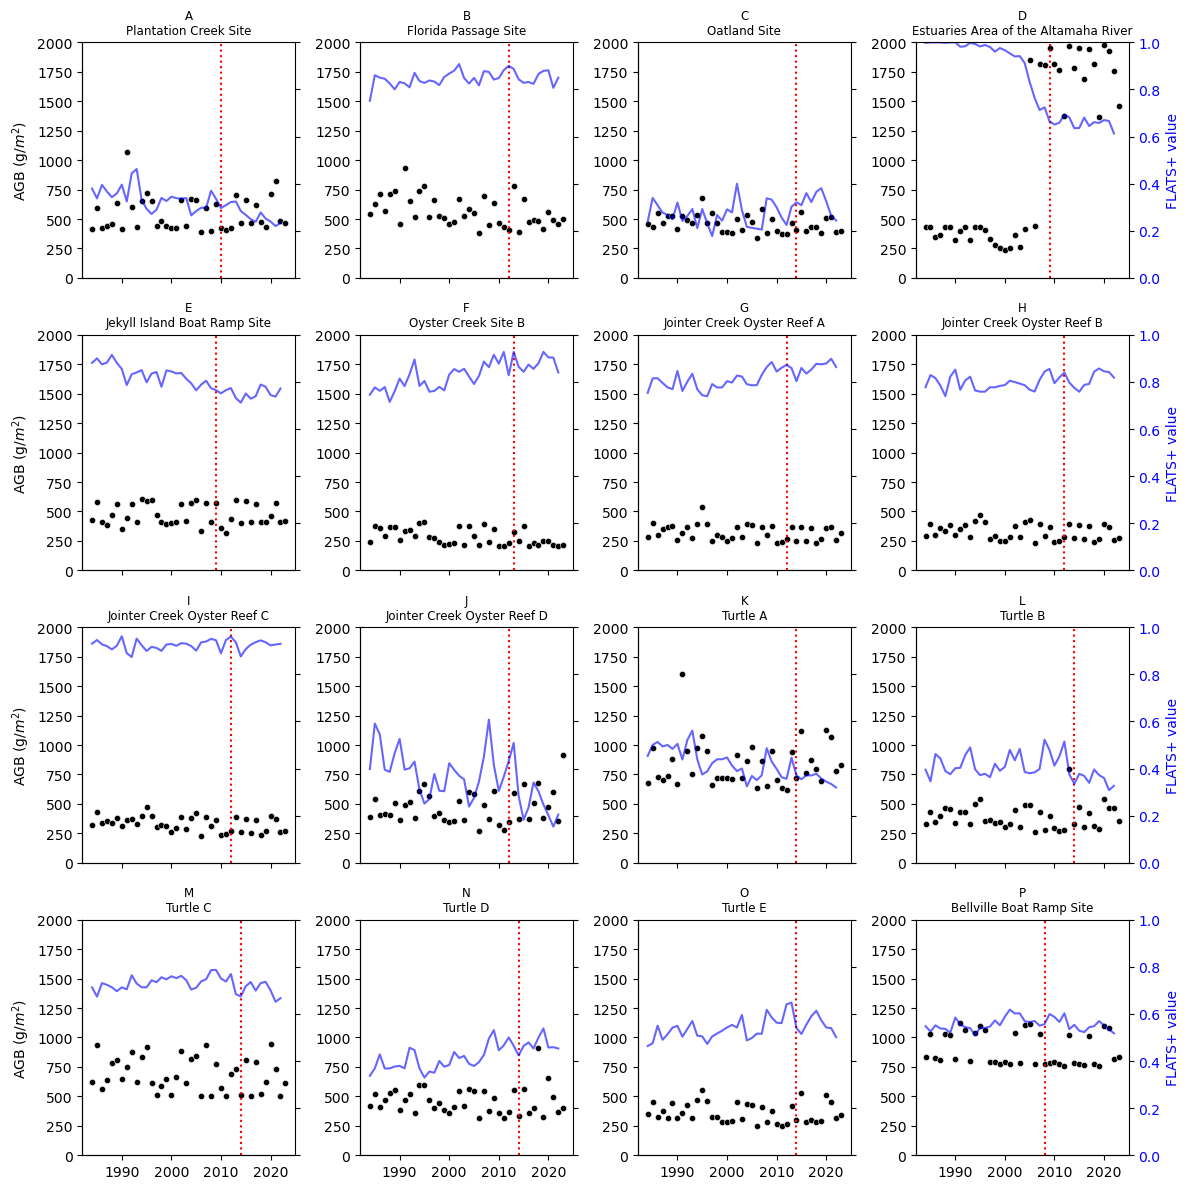

In [11]:
# Create the FacetGrid
g = sns.FacetGrid(df_merged, col="Site", col_wrap=4, height=3, sharey=True)

site_type_map = df_merged.groupby('Site')['type'].first().to_dict()

import string

# Get sites in the order you want
sites = sorted(df_merged["Site"].unique())

# Create A, B, C, ...
site_letter_map = {
    site: letter
    for site, letter in zip(g.col_names, string.ascii_uppercase)
}


# Map the scatterplot
g.map(sns.scatterplot, "year", "biomass", marker='o', color='black', s=20)

for site_name, ax in g.axes_dict.items():
    
    # Get the type for this site
    site_type = site_type_map.get(site_name, "Unknown")
    
    site_letter = site_letter_map[site_name]
    
    # Update the title to include both Site and Type
    ax.set_title(f"{site_name}\n{site_type}", size=8.5)
    
    # Update the title to include both Site and Type
    ax.set_title(f"{site_letter}\n{site_name}", size=8.5)
    
    # 1. Create the second axis
    ax2 = ax.twinx()
    
    # 2. Filter data for this specific site
    site_data = df_merged[df_merged["Site"] == site_name]
    
    # 3. Plot the flats_mean on the twin axis
    ax2.plot(site_data["year"], site_data["flats_mean"], color='blue', alpha=0.6, label='Flats')
    
    # 4. Conditionally set labels to avoid repetition
    # Only show the ylabel for the right-most columns
    if ax.is_last_col():
        ax2.set_ylabel("FLATS+ value", color='blue')
    else:
        ax2.set_ylabel("")
        # Hide tick labels for non-right columns if preferred
        ax2.tick_params(axis='y', labelright=False)
        
    ax2.tick_params(axis='y', labelcolor='blue')
    ax2.set_ylim(0, 1)
    
    # Add your existing vertical line
    install_year = site_data["Install_year"].iloc[0]
    ax.axvline(x=install_year, linestyle=":", color="red", linewidth=1.5)

g.set_axis_labels("", "AGB (g/$m^2$)")
g.set(ylim=(0, 2000))
'''g.set_titles("{col_name}", size = 8.5)
'''    
plt.tight_layout()


##Save at high res
import os
output_dir = r'F:\Figures_PaperII'
file_name = 'FIXED_resorationsitetrends_3_oysters.tif'

save_path = os.path.join(output_dir, file_name)

# plt.savefig(save_path, bbox_inches='tight', dpi=1000)
plt.show()

In [12]:
import statsmodels.formula.api as smf

# Create a 'years_since_install' column
df_merged['years_since_install'] = df_merged['year'] - df_merged['Install_year']
df_merged['time_since_intervention'] = (df_merged['year'] - df_merged['Install_year']).clip(lower=0)
df_merged['installation_year'] = df_merged['Install_year']

# Clean the data before modeling
df_clean = df_merged.dropna(subset=['biomass', 'flats_mean', 'years_since_install', 'Site']).copy()
df_clean = df_clean.reset_index(drop=True)

In [13]:
##Combining restoration site trends with synthetic control trends in a single file
xx = pd.read_csv('C:/Users/arj26323/Documents/Data/GA_Conservation/df_rest_sites.csv')
yy = pd.read_csv('C:/Users/arj26323/Documents/Data/GA_Conservation/synthetic_contols/df_syntheticcontrol_sites.csv')
xx['Treatment'] = 'Altered'
yy['Treatment'] = 'Control'

yy["SiteTreat"] = yy["Site"] + "_C"
xx["SiteTreat"] = xx["Site"] + "_A"

zz = df_all = pd.concat([xx, yy], ignore_index=True)

zz

,Site,Install_year,type,year,biomass,flats_mean,years_since_install,time_since_intervention,installation_year,PostInstall,YearSinceInstall,resid,Treatment,SiteTreat
0,Plantation Creek Site,2010,Oyster Reef,1984,415.569183,0.379410,-26,0,2010,0,0,-157.612103,Altered,Plantation Creek Site_A
1,Florida Passage Site,2012,Oyster Reef,1984,546.787598,0.752100,-28,0,2012,0,0,-56.665983,Altered,Florida Passage Site_A
2,Oatland Site,2014,Oyster Reef,1984,454.848907,0.239140,-30,0,2014,0,0,-45.020865,Altered,Oatland Site_A
3,Jekyll Island Boat Ramp Site,2009,Oyster Reef,1984,426.000030,0.880526,-25,0,2009,0,0,-76.927027,Altered,Jekyll Island Boat Ramp Site_A
4,Oyster Creek Site B,2013,Oyster Reef,1984,239.060226,0.745511,-29,0,2013,0,0,-84.032465,Altered,Oyster Creek Site B_A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,Turtle B,2014,Oyster Reef,2022,452.692535,0.316537,8,8,2014,1,8,NaN,Control,Turtle B_C
1049,Turtle C,2014,Oyster Reef,2022,379.104492,0.593493,8,8,2014,1,8,NaN,Control,Turtle C_C
1050,Turtle D,2014,Oyster Reef,2022,468.425079,0.177950,8,8,2014,1,8,NaN,Control,Turtle D_C
1051,Turtle E,2014,Oyster Reef,2022,424.402832,0.276992,8,8,2014,1,8,NaN,Control,Turtle E_C


In [14]:
#Export CSV file
out_dir = os.path.expanduser('~/Downloads')
out_csv = os.path.join(out_dir, 'df_rest_sites.csv')
# df.to_csv(out_csv, index = False)

In [161]:
#Fin